# **TP 2 : Classification pour la détection du cancer de la prostate (PICAI)**

## **Problématique & Objectif**

Dans ce TP, vous allez explorer la **classification binaire** pour prédire la présence ou l'absence d'un cancer de la prostate chez un patient (variable cible : `case_csPCa` → YES/NO).

### **Contexte clinique**
Vous disposez de mesures cliniques réelles incluant :
- **Données démographiques** : `patient_age`
- **Marqueurs sanguins** : `psa` (Antigène Spécifique de la Prostate), `psad` (densité PSA)
- **Mesures physiques** : `prostate_volume`
- **Informations histopathologiques** : `histopath_type`, `case_ISUP`

### **Résultats attendus**
À la fin de ce TP, vous serez capable de :
- Charger et explorer des données de classification  
- Préparer des données pour la modélisation (réutilisant les techniques du TP1)  
- Entraîner et comparer des modèles de classification  
- Évaluation des performances à l'aide de métriques spécifiques à la classification.

## **Partie 1 : Chargement et exploration des données**

Dans cette partie, vous allez charger le jeu de données, puis effectuer une première exploration pour comprendre sa structure, son contenu et identifier les problèmes à traiter. Vous avez déjà maîtrisé l'exploration des données dans le TP précédent. Nous nous concentrons sur les spécificités d'une tâche de **classification**.


In [1]:
# ==============================================================================
# IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation et modélisation
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modèles de classification
from sklearn.linear_model import LogisticRegression
# Métriques et visualisations
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

### **Étape 1.1 : Chargement du jeu de données**

**Note** : Le fichier `PICAI.csv` doit être disponible localement ou sur Google Drive.

In [2]:
# Charger les données (adapter le chemin selon votre environnement)
# Pour Google Colab : montez le Drive d'abord
# from google.colab import drive
# drive.mount('/content/gdrive')
# file_path = '/content/gdrive/MyDrive/PICAI.csv'

file_path = 'PICAI.csv'  # Ajuster le chemin si nécessaire

try:
    df = pd.read_csv(file_path)
    print(f" Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
except FileNotFoundError:
    print(f" Fichier non trouvé : {file_path}")
    print("Assurez-vous que le fichier est dans le répertoire courant ou ajustez le chemin.")

 Dataset chargé : 1500 lignes, 12 colonnes


### **Étape 1.2 : Exploration des données**

A l'aide des fonctions vues précédemment (`.head()`, `.info()`, `.describe()`), identifiez la structure et les problèmes principaux de ce jeu de données.

In [3]:
print("\n--- Informations générales sur le dataset (df.info()) ---")
# Observez les types de données et le nombre de valeurs non-nulles par colonne
df.info()

print("\n--- Statistiques descriptives des colonnes numériques (df.describe()) ---")
# Prêtez attention aux min/max, moyennes et quartiles. Des valeurs vous paraissent-elles anormales ?
df.describe()


--- Informations générales sur le dataset (df.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       1500 non-null   int64  
 1   study_id         1500 non-null   int64  
 2   mri_date         1500 non-null   str    
 3   patient_age      1500 non-null   int64  
 4   psa              1460 non-null   float64
 5   psad             1049 non-null   float64
 6   prostate_volume  1473 non-null   float64
 7   histopath_type   1001 non-null   str    
 8   lesion_GS        1001 non-null   str    
 9   lesion_ISUP      1001 non-null   str    
 10  case_ISUP        1500 non-null   int64  
 11  case_csPCa       1500 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 140.8 KB

--- Statistiques descriptives des colonnes numériques (df.describe()) ---


,patient_id,study_id,patient_age,psa,psad,prostate_volume,case_ISUP
count,1500.000000,1.500000e+03,1500.000000,1460.000000,1049.000000,1473.000000,1500.000000
mean,10735.602667,1.000750e+06,65.595333,11.932397,0.224662,65.045472,0.942000
std,425.311791,4.331570e+02,7.191527,14.939071,0.404288,36.449618,1.333099
min,10000.000000,1.000000e+06,35.000000,0.100000,0.010000,4.000000,0.000000
25%,10368.750000,1.000375e+06,61.000000,5.882500,0.090000,40.000000,0.000000
50%,10733.500000,1.000750e+06,66.000000,8.500000,0.140000,57.000000,0.000000
75%,11101.250000,1.001124e+06,70.000000,13.000000,0.220000,80.000000,2.000000
max,11475.000000,1.001499e+06,92.000000,224.000000,7.000000,308.000000,5.000000


### **Étape 1.3 : Distribution de la variable cible**

**Important pour la classification** : Vérifiez si les classes de la variable cible `case_csPCa` sont équilibrées à l'aide de la fonction `value_counts()`.

In [5]:
# TODO: Utilisez .value_counts() pour afficher la répartition des classes de la variable cible
df.value_counts()


patient_id  study_id  mri_date    patient_age  psa    psad  prostate_volume  histopath_type  lesion_GS    lesion_ISUP  case_ISUP  case_csPCa
10004       1000004   2020-10-21  67           8.00   0.10  78.0             SysBx+MRBx      0+0,0+0      0,0          0          NO            1
10005       1000005   2012-07-18  64           12.10  0.24  51.0             MRBx            4+3,0+0      3,0          3          YES           1
10006       1000006   2020-10-23  73           6.20   0.23  27.0             SysBx+MRBx      0+0,3+3      0,1          1          NO            1
10007       1000007   2020-10-31  68           3.83   0.09  41.0             SysBx+MRBx      3+3          1            1          NO            1
10008       1000008   2020-12-06  81           11.10  0.20  56.0             SysBx+MRBx      4+3,3+4      3,2          3          YES           1
                                                                                                                                 

### **Étape 1.4 : identification des problèmes dans le jeu de données & Sélection des variables**
Certaines colonnes sont des identifiants ou contiennent des informations très complexes qui dépassent le cadre de ce TP d'introduction. Nous allons les exclure pour nous concentrer sur les features les plus directement utilisables.

- `patient_id`, `study_id` : Identifiants, non pertinents pour la prédiction directe.
- `mri_date` : Date, nécessite un traitement spécifique (ex: ancienneté) qui peut complexifier le TP.
- `lesion_GS`, `lesion_ISUP`, `case_ISUP` : Contiennent des scores multiples ou des formats complexes ("0+0", "N/A", valeurs séparées par virgules). Leur traitement pour en extraire des features utilisables est une tâche d'ingénierie de features avancée.

In [6]:
print("\n--- Sélection et exclusions des features ---")

# Colonnes à exclure pour ce TP d'introduction
columns_to_drop = ['patient_id', 'study_id', 'mri_date', 'lesion_GS', 'lesion_ISUP','case_ISUP']
df_processed = df.drop(columns=columns_to_drop, errors='ignore') # 'errors='ignore'' pour éviter une erreur si la colonne n'existe pas
print(f"Colonnes exclues : {columns_to_drop}")
print(f"Nouvelle taille du dataset : {df_processed.shape[0]} lignes, {df_processed.shape[1]} colonnes.")
print("\nAperçu du dataset après exclusion de colonnes :")
print(df_processed.head())


--- Sélection et exclusions des features ---
Colonnes exclues : ['patient_id', 'study_id', 'mri_date', 'lesion_GS', 'lesion_ISUP', 'case_ISUP']
Nouvelle taille du dataset : 1500 lignes, 6 colonnes.

Aperçu du dataset après exclusion de colonnes :
   patient_age   psa  psad  prostate_volume histopath_type case_csPCa
0           73   7.7   NaN             55.0           MRBx         NO
1           64   8.7  0.09            102.0            NaN         NO
2           58   4.2  0.06             74.0            NaN         NO
3           72  13.0   NaN             71.5          SysBx         NO
4           67   8.0  0.10             78.0     SysBx+MRBx         NO


**Problème 1 : Identification et Quantification des Valeurs Manquantes (NaNs)**

In [7]:
print("\n--- Nombre de valeurs manquantes par colonne (NaNs) après exclusion ---")
print(df_processed.isnull().sum())


--- Nombre de valeurs manquantes par colonne (NaNs) après exclusion ---
patient_age          0
psa                 40
psad               451
prostate_volume     27
histopath_type     499
case_csPCa           0
dtype: int64


**Problème 2 : Identification visuelle des valeurs aberrantes (Outliers) numériques**



--- Visualisation des valeurs aberrantes (Outliers) dans les colonnes numériques ---


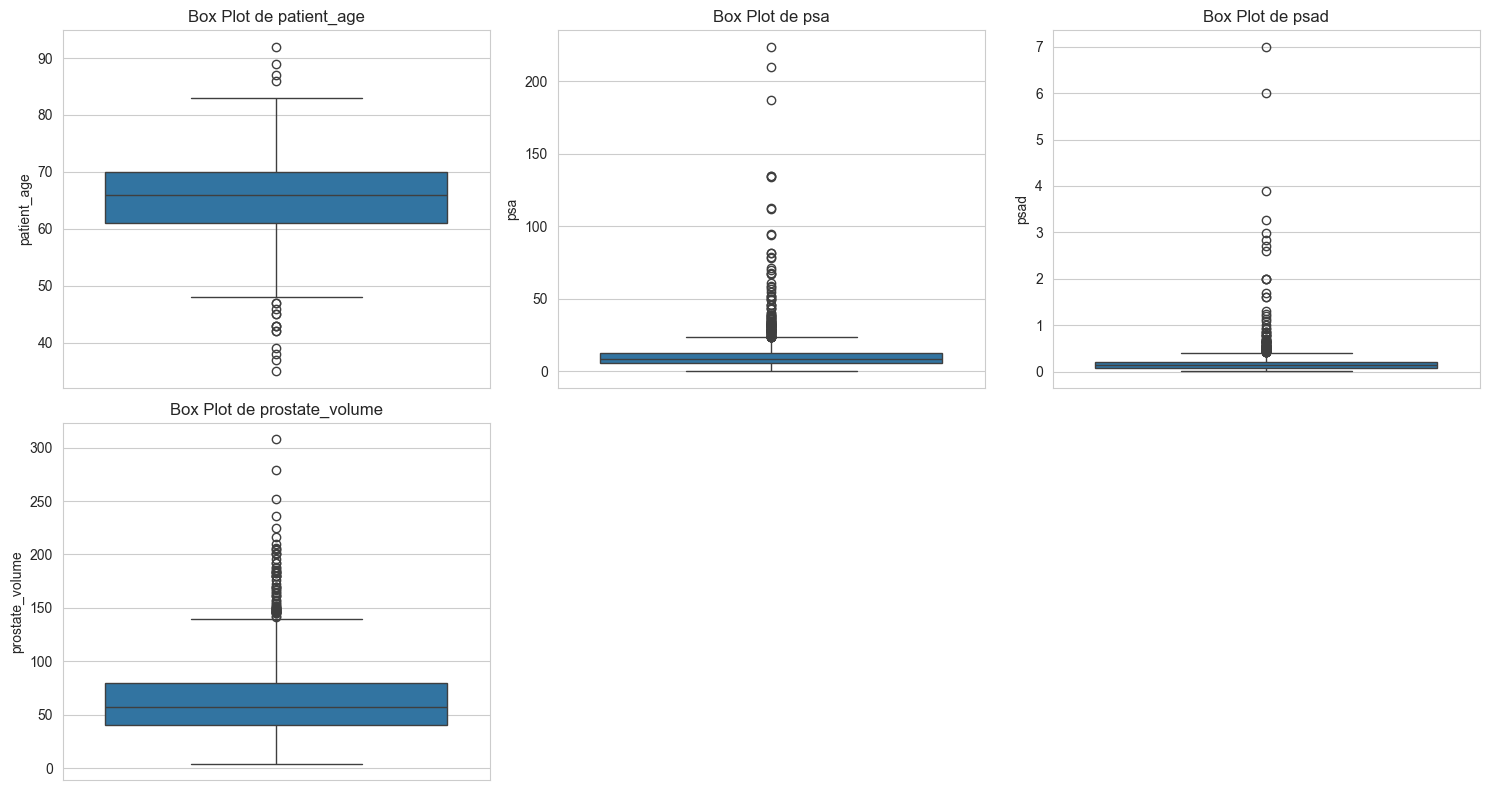

In [8]:
print("\n--- Visualisation des valeurs aberrantes (Outliers) dans les colonnes numériques ---")

# Identifier toutes les colonnes numériques, en excluant la cible 'case_csPCa' qui est ici un string 'YES'/'NO'
# et 'case_ISUP' que nous allons traiter comme une variable catégorielle ordinale pour ce TP
numerical_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
# Nous allons considérer 'case_ISUP' comme catégorielle ordinale pour l'encodage plus tard, donc l'exclure ici
numerical_cols_for_outliers = [col for col in numerical_cols if col not in ['case_ISUP']]

if not numerical_cols_for_outliers:
    print("Aucune colonne numérique trouvée pour la visualisation des outliers (hors 'case_ISUP').")
else:
    n_plots = len(numerical_cols_for_outliers)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(numerical_cols_for_outliers):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(y=df_processed[col])
        plt.title(f'Box Plot de {col}')
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

**Problème 3 : Détection des incohérences dans les variables catégorielles**

In [9]:
print("\n--- Fréquence des catégories dans 'histopath_type' ---")
# Y a-t-il des catégories que vous n'attendiez pas ou des erreurs de frappe ?
print(df_processed['histopath_type'].value_counts(dropna=False))


--- Fréquence des catégories dans 'histopath_type' ---
histopath_type
MRBx          549
NaN           499
SysBx         217
SysBx+MRBx    210
RP             25
Name: count, dtype: int64


## **Partie 2 : Préparation des données**

Nous allons maintenant corriger les problèmes identifiés et préparer les données pour le modèle. Cette partie est similaire à celle effectuée dans le TP1. Pour cela, dans ce TP, il suffit de comprendre les étapes de préparation des données et d'exécuter le code fourni.

**Objectifs** :
- Séparer les features (X) de la variable cible (y).
- Convertir la cible `case_csPCa` en format numérique (0/1).
- Diviser le dataset en ensembles d'entraînement et de test en stratifiant par la cible.
- Identifier les types de colonnes (numériques, catégorielles).
- Traiter les valeurs manquantes (imputation).
- Gérer les valeurs aberrantes (outliers) pour les colonnes numériques pertinentes.
- Encoder les variables catégorielles.
- Standardiser les features numériques.

### **Étape 2.1 : Séparation X (features) et y (cible)**


La première étape est de distinguer les variables d'entrée (features) de la variable que nous voulons prédire (cible). Pour le jeu de données PICAI, la cible est `case_csPCa`.

**Tâche :** Créez deux DataFrames ou Series : $X$ contenant toutes les features, et $y$ contenant la colonne `case_csPCa`.

In [10]:
print("\n--- Séparation des Features (X) et de la Cible (y) ---")

# Créer y (cible) : convertir YES/NO en 1/0
y = (df_processed['case_csPCa'] == 'YES').astype(int)

# Créer X (features) : toutes les colonnes sauf la cible
X = df_processed.drop(columns=['case_csPCa'])

print(f"  - X : {X.shape}")
print(f"  - y : {y.shape}")
print(f"\nDistribution de la cible (après encodage) :")
print(y.value_counts())


--- Séparation des Features (X) et de la Cible (y) ---
  - X : (1500, 5)
  - y : (1500,)

Distribution de la cible (après encodage) :
case_csPCa
0    1075
1     425
Name: count, dtype: int64


### **Étape 2.2 : Division train/test (stratifiée)**

**Stratification** : Assure que les proportions de classes sont maintenues dans train et test.

In [11]:
# Division stratifiée (important pour les classes déséquilibrées)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Forme de X_train : {X_train.shape}")
print(f"Forme de X_test : {X_test.shape}")
print(f"Forme de y_train : {y_train.shape}")
print(f"Forme de y_test : {y_test.shape}")

print("\nDistribution de la cible dans l'ensemble d'entraînement :")
print(y_train.value_counts(normalize=True))
print("Distribution de la cible dans l'ensemble de test :")
print(y_test.value_counts(normalize=True))

Forme de X_train : (1200, 5)
Forme de X_test : (300, 5)
Forme de y_train : (1200,)
Forme de y_test : (300,)

Distribution de la cible dans l'ensemble d'entraînement :
case_csPCa
0    0.716667
1    0.283333
Name: proportion, dtype: float64
Distribution de la cible dans l'ensemble de test :
case_csPCa
0    0.716667
1    0.283333
Name: proportion, dtype: float64


### **Étape 2.3 : Identification des types de colonnes (numériques et catégorielles)**

In [12]:
print("\n--- Identification des Types de Colonnes ---")

# Colonnes numériques
numerical_cols = ['patient_age', 'psa', 'psad', 'prostate_volume']

# Colonnes catégorielles (incluant 'case_ISUP' comme ordinale pour l'encodage)
categorical_cols = ['histopath_type']

print(f"Colonnes numériques : {numerical_cols}")
print(f"Colonnes catégorielles : {categorical_cols}")

# Vérification que toutes les colonnes de X_train sont couvertes
all_features = numerical_cols + categorical_cols
missing_from_list = set(X_train.columns) - set(all_features)
if missing_from_list:
    print(f"Attention : Les colonnes suivantes ne sont pas catégorisées : {missing_from_list}")


--- Identification des Types de Colonnes ---
Colonnes numériques : ['patient_age', 'psa', 'psad', 'prostate_volume']
Colonnes catégorielles : ['histopath_type']


### **Étape 2.4 : Traitement des valeurs manquantes (imputation)**

**Tâche** : Appliquez des stratégies d'imputation différentes pour les colonnes numériques et catégorielles.

- Pour les numériques : Utilisez SimpleImputer avec la stratégie median (médiane, moins sensible aux outliers que la moyenne).

- Pour les catégorielles : Utilisez SimpleImputer avec la stratégie most_frequent (mode).

In [13]:
print("\n--- Traitement des Valeurs Manquantes (Imputation) ---")

# Identifier les colonnes numériques et catégorielles
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"Colonnes numériques à imputer : {numerical_cols}")
print(f"Colonnes catégorielles à imputer : {categorical_cols}")

# Imputer numérique (médiane)
if len(numerical_cols) != 0:
  imputer_numerical = SimpleImputer(strategy='median')
  X_train[numerical_cols] = imputer_numerical.fit_transform(X_train[numerical_cols])
  X_test[numerical_cols] = imputer_numerical.transform(X_test[numerical_cols]) # Utiliser transform pour le test !

# Imputer catégorique (mode)
if len(categorical_cols) != 0:
  imputer_categorical = SimpleImputer(strategy='most_frequent')
  X_train[categorical_cols] = imputer_categorical.fit_transform(X_train[categorical_cols])
  X_test[categorical_cols] = imputer_categorical.transform(X_test[categorical_cols])

print("\nNombre de NaNs après imputation (X_train) :")
print(X_train.isnull().sum().sum()) # Devrait être 0
print("Nombre de NaNs après imputation (X_test) :")
print(X_test.isnull().sum().sum()) # Devrait être 0


--- Traitement des Valeurs Manquantes (Imputation) ---
Colonnes numériques à imputer : ['patient_age', 'psa', 'psad', 'prostate_volume']
Colonnes catégorielles à imputer : ['histopath_type']

Nombre de NaNs après imputation (X_train) :
0
Nombre de NaNs après imputation (X_test) :
0


C:\Users\julie\AppData\Local\Temp\ipykernel_40172\3825933276.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include='object').columns.tolist()


### **Étape 2.5 : Gestion des valeurs aberrantes (outliers) numériques**
Nous allons appliquer le capping vu dans le TP1 aux colonnes numériques `psa` et `prostate_volume` où les outliers peuvent être cliniquement significatifs mais fausser un modèle linéaire.


--- Gestion des Valeurs Aberrantes (Outliers) Numériques ---
Outliers traités pour la colonne 'psa' avec bornes [-3.31, 21.25]
Outliers traités pour la colonne 'prostate_volume' avec bornes [-18.50, 137.50]


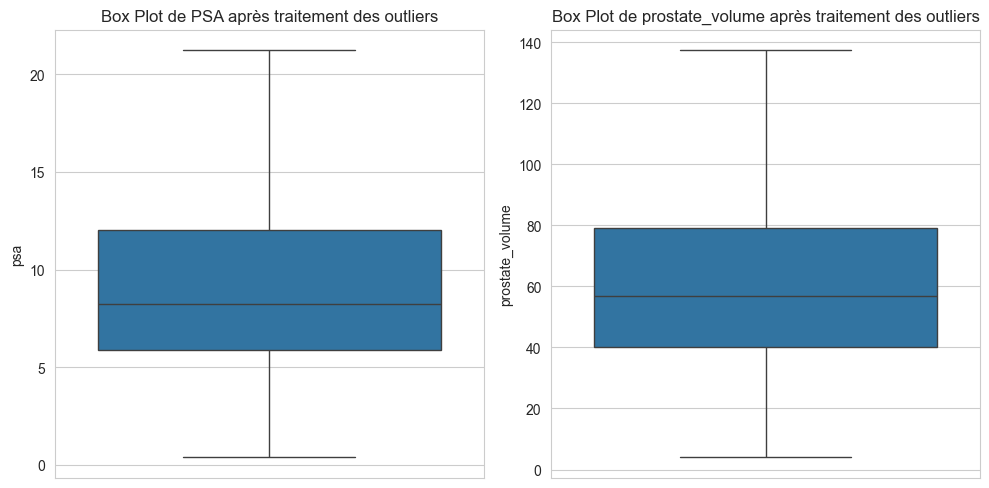

In [14]:
print("\n--- Gestion des Valeurs Aberrantes (Outliers) Numériques ---")

# Colonnes avec outliers à traiter
outlier_cols_to_cap = ['psa', 'prostate_volume'] # Basé sur l'EDA et la connaissance clinique

for col in outlier_cols_to_cap:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    # On peut ajuster le facteur 1.5 pour être plus ou moins agressif.
    # Pour des données cliniques, 3*IQR est parfois utilisé pour des outliers plus extrêmes
    # mais gardons 1.5*IQR pour ce TP.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

    print(f"Outliers traités pour la colonne '{col}' avec bornes [{lower_bound:.2f}, {upper_bound:.2f}]")

# Vérification visuelle après écrêtage
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=X_train['psa'])
plt.title('Box Plot de PSA après traitement des outliers')
plt.subplot(1, 2, 2)
sns.boxplot(y=X_train['prostate_volume'])
plt.title('Box Plot de prostate_volume après traitement des outliers')
plt.tight_layout()
plt.show()

### **Étape 2.6 : Encodage des variables catégorielles**

`histopath_type` sera encodée avec `OneHotEncoder`.

Les modèles de machine learning ne comprennent que les nombres, pas le texte. 
**OneHotEncoder** transforme chaque catégorie en colonne binaire (0 ou 1).

**Exemple avec `histopath_type`** :
```
Avant :                  Après OneHotEncoding :
histopath_type           MRBx  SysBx  RP
"MRBx"        →            1     0     0
"SysBx"      →            0     1     0
"RP"         →            0     0     1
```

Chaque patient a exactement une valeur à 1 (sa catégorie) et les autres à 0. 

In [ ]:
print("\n--- Encodage des Variables Catégorielles ---")

# Vérification des catégories dans 'histopath_type' avant encodage
print("\nCatégories uniques dans 'histopath_type' avant encodage:")
print(X_train['histopath_type'].value_counts(dropna=False))

# Vérification des catégories dans 'case_ISUP' avant encodage
#print("\nCatégories uniques dans 'case_ISUP' avant encodage:")
#print(X_train['case_ISUP'].value_counts(dropna=False))

# One-Hot Encoding pour toutes les colonnes catégorielles
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Appliquer l'encodage
X_train_encoded_cat = one_hot_encoder.fit_transform(X_train[categorical_cols])
X_test_encoded_cat = one_hot_encoder.transform(X_test[categorical_cols])

# Créer des DataFrames pour les colonnes encodées
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_cols)
X_train_encoded_cat_df = pd.DataFrame(X_train_encoded_cat, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_cat_df = pd.DataFrame(X_test_encoded_cat, columns=encoded_feature_names, index=X_test.index)

# Supprimer les colonnes catégorielles originales et concaténer les nouvelles colonnes encodées
X_train = X_train.drop(columns=categorical_cols, axis=1)
X_test = X_test.drop(columns=categorical_cols, axis=1)

X_train = pd.concat([X_train, X_train_encoded_cat_df], axis=1)
X_test = pd.concat([X_test, X_test_encoded_cat_df], axis=1)

print(f"\nForme de X_train après encodage : {X_train.shape}")
print(f"Forme de X_test après encodage : {X_test.shape}")
print("\nAperçu des colonnes après encodage (X_train.head()) :")
print(X_train.head())


--- Encodage des Variables Catégorielles ---

Catégories uniques dans 'histopath_type' avant encodage:
histopath_type
MRBx          844
SysBx         169
SysBx+MRBx    166
RP             21
Name: count, dtype: int64


ValueError: Cannot specify both 'axis' and 'index'/'columns'

### **Étape 2.7 : Standardisation des features numériques**

**Tâche** : Appliquez `StandardScaler` à toutes les colonnes numériques de X_train et X_test.

In [ ]:
print("\n--- Standardisation des Features Numériques ---")

# Les colonnes numériques à standardiser sont celles qui étaient dans 'numerical_cols'
# et qui sont toujours dans X_train après l'encodage des catégorielles.
# On exclut les colonnes déjà encodées qui sont binaires.
final_numerical_cols = [col for col in numerical_cols if col in X_train.columns]

scaler = StandardScaler()

X_train[final_numerical_cols] = scaler.fit_transform(X_train[final_numerical_cols])
X_test[final_numerical_cols] = scaler.transform(X_test[final_numerical_cols])

print("\nAperçu de X_train après standardisation :")
print(X_train.head())
print(f"Forme finale de X_train : {X_train.shape}")
print(f"Forme finale de X_test : {X_test.shape}")

## **Partie 3 : Entraînement des modèles de classification**


**Objectifs de cette partie :**
- Entraîner un modèle de **Régression logistique** sur l'ensemble d'entraînement.
- Utiliser ce modèle pour faire des prédictions (classes et probabilités) sur l'ensemble de test.



### **Étape 3.1 : Entraînement d'un modèle de régression logistique**

**Tâche :**

- Importez la classe `LogisticRegression` de `sklearn.linear_model`.
- Instanciez un objet `LogisticRegression`.
- Entraînez le modèle sur X_train et y_train.

In [ ]:
print("\n--- Entraînement du Modèle de Régression Logistique ---")

# TODO: Importer LogisticRegression

# TODO: Instancier le modèle de régression logistique

# TODO: Entraîner le modèle sur les données d'entraînement (X_train, y_train)
print("Entraînement du modèle...")

print("Modèle entraîné avec succès.")

### **Étape 3.2 : prédictions sur les données train et test**
Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions sur l'ensemble de train (X_train) et test (X_test). L'évaluation sur l'ensemble test permet d'évaluer la capacité du modèle à généraliser sur des données jamais vues pendant l'entraînement.

**Tâche :** Utilisez la méthode `.predict()` de votre modèle entraîné pour obtenir les prédictions sur X_train et X_test. Y a-t-il une différence entre les performances du modèle sur les données d'apprentissage et les données d'entraînement ? Expliquez.

In [ ]:
print("\n--- Prédictions sur l'Ensemble de Train ---")

# TODO: Faire des prédictions sur X_train
y_pred =
y_pred_proba =
print("Prédictions (classes) générées.")
print("Probabilités de la classe positive générées.")

print("\nComparaison des 10 premières vraies valeurs et prédictions :")
comparison_df = pd.DataFrame({
    'Vraie Classe': ,
    'Prédiction': ,
    'Probabilité (Classe 1)':
})
print(comparison_df)

print("\n--- Prédictions sur l'Ensemble de Test ---")

# TODO: Faire des prédictions sur X_test

y_pred =
y_pred_proba =
print("Prédictions (classes) générées.")
print("Probabilités de la classe positive générées.")

print("\nComparaison des 10 premières vraies valeurs et prédictions :")
comparison_df = pd.DataFrame({
    'Vraie Classe': ,
    'Prédiction': ,
    'Probabilité (Classe 1)':
})
print(comparison_df)

# **Partie 4 : Évaluation des modèles de classification : métriques clés et interprétation**
Lorsqu'on développe un modèle de classification, l'objectif est de prédire correctement la classe d'une nouvelle observation. Cependant, un simple "taux de bonnes réponses" (*accuracy*) est souvent insuffisant, voire trompeur, surtout face à des problèmes complexes ou déséquilibrés. Une évaluation rigoureuse nécessite de comprendre les différents types d'erreurs que le modèle peut commettre et d'utiliser des métriques adaptées.

Pour expliquer ces concepts, nous allons prendre l'exemple de notre problème de détection du cancer de la prostate, où :

- La classe **Positive** $(1)$ signifie "Cancer présent".
- La classe **Négative** $(0)$ signifie "Pas de cancer".

Les Bases : **Vrais Positifs**, **Vrais Négatifs**, **Faux Positifs**, **Faux Négatifs :**
Ces quatre termes sont les éléments de toutes les métriques de classification et sont dérivés de la comparaison entre la prédiction du modèle et la réalité (la vraie classe).

**Vrai Positif (VP ou TP - True Positive) :** Le modèle a prédit la classe Positive (Cancer) et la vraie classe est effectivement Positive (Cancer).

**Vrai Négatif (VN ou TN - True Negative) :** Le modèle a prédit la classe Négative (Pas de cancer) et la vraie classe est effectivement Négative (Pas de cancer).

**Faux Positif (FP - False Positive) :** Le modèle a prédit la classe Positive (Cancer) mais la vraie classe est Négative (Pas de cancer). C'est une erreur de "Type I".

**Faux Négatif (FN - False Negative) :** Le modèle a prédit la classe Négative (Pas de cancer) mais la vraie classe est Positive (Cancer). C'est une erreur de "Type II".

## La Matrice de confusion
La matrice de confusion est un tableau qui résume visuellement la performance du modèle en regroupant les VP, VN, FP, et FN. C'est l'outil de base pour comprendre la nature des erreurs de classification.

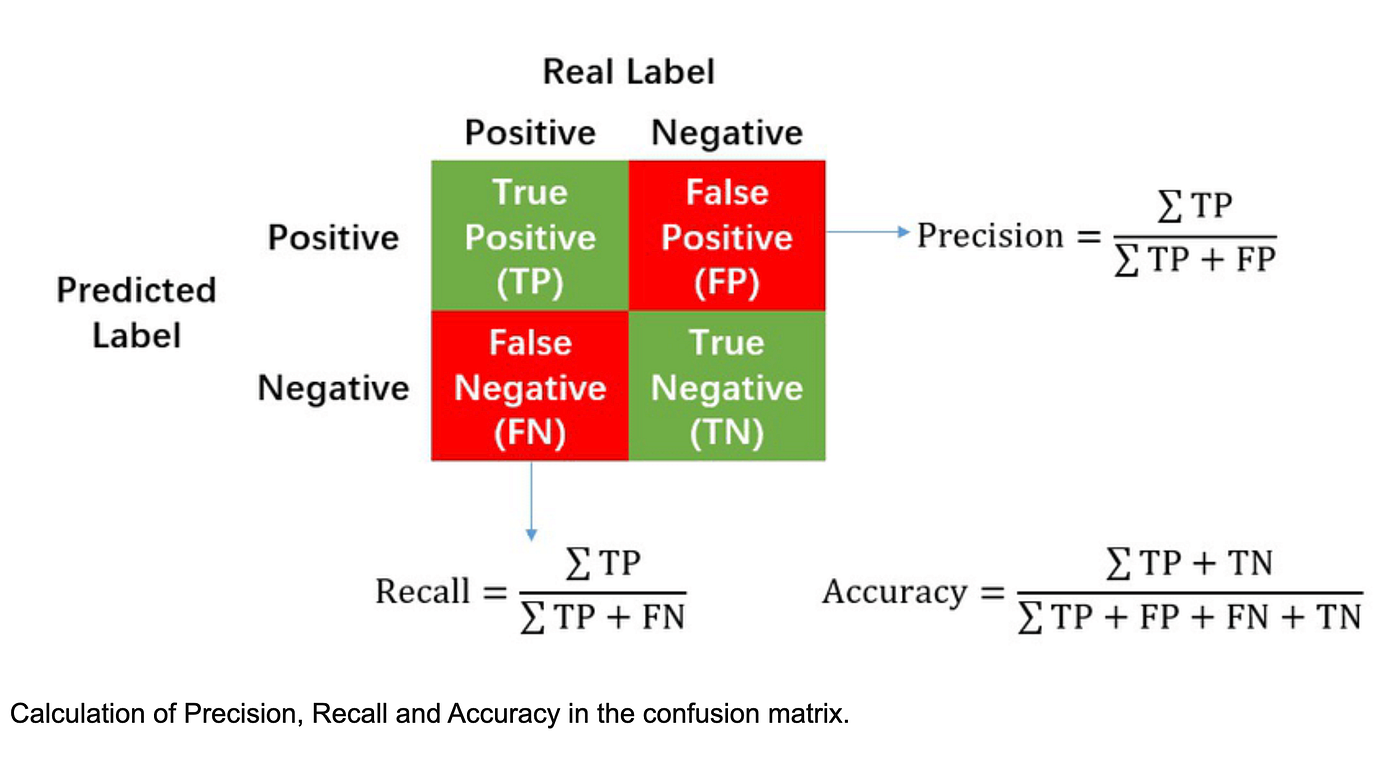

**Métriques dérivées de la matrice de  onfusion**

Ces métriques quantifient différents aspects de la performance du modèle, en utilisant les VP, VN, FP, FN.

- **Accuracy (Précision globale)**: Dans notre cas, c'est le pourcentage de patients pour lesquels le modèle a correctement prédit s'ils avaient ou non le cancer. Peut être très trompeuse si les classes sont déséquilibrées. Si 95% des patients n'ont pas le cancer, un modèle qui prédit toujours "Pas de cancer" aura 95% d'accuracy, ce qui est excellent en apparence, mais il ne détectera aucun cancer (FN élevé).
- **Precision (Précision de la classe Positive)**: Dans notre cas, parmi tous les patients que le modèle a classés comme ayant le cancer, quelle est la proportion de ceux qui ont réellement le cancer. Lorsque le coût d'un Faux Positif (FP) est élevé. Par exemple, si une fausse alarme mène à un traitement invasif et dangereux pour un patient en bonne santé, on voudra une haute précision.
- **Recall (Rappel, Sensibilité, True Positive Rate - TPR)** : Parmi toutes les observations qui étaient réellement positives, quelle proportion a été correctement identifiée par le modèle. Dans notre cas, parmi tous les patients qui ont réellement le cancer, quelle proportion a été correctement détectée par le modèle. Lorsque le coût d'un Faux Négatif (FN) est élevé. C'est souvent le cas en médecine où rater un diagnostic de cancer peut avoir des conséquences fatales. On cherche à minimiser les FN.
- **Specificity (Spécificité, True Negative Rate - TNR)**: Parmi toutes les observations qui étaient réellement négatives, quelle proportion a été correctement identifiée par le modèle. Dans notre cas, parmi tous les patients qui n'ont pas le cancer, quelle proportion a été correctement identifiée comme étant saine. Relation avec FPR : La Spécificité est l'inverse du Taux de Faux Positifs (FPR) : Specificity=1−FPR.
- **F1-Score**: Moyenne harmonique de la Précision et du Rappel. Il pénalise les modèles qui ont une très bonne Précision mais un très mauvais Rappel (ou inversement).

​Dans notre cas, c'est la proportion de patients sains que le modèle a, à tort, classés comme ayant le cancer.
Quand l'utiliser : Indispensable pour la courbe ROC. Un faible FPR est souhaitable.

## **La Courbe ROC (Receiver Operating Characteristic)**

Les modèles de classification, en particulier les modèles probabilistes comme la Régression Logistique, ne donnent pas seulement une étiquette "0" ou "1", mais aussi une probabilité que l'observation appartienne à la classe positive. Pour obtenir une étiquette binaire, un seuil de classification est appliqué (par exemple, si la probabilité > 0.5, alors "Cancer", sinon "Pas de cancer").

La courbe ROC évalue la performance du modèle indépendamment du seuil de classification choisi.

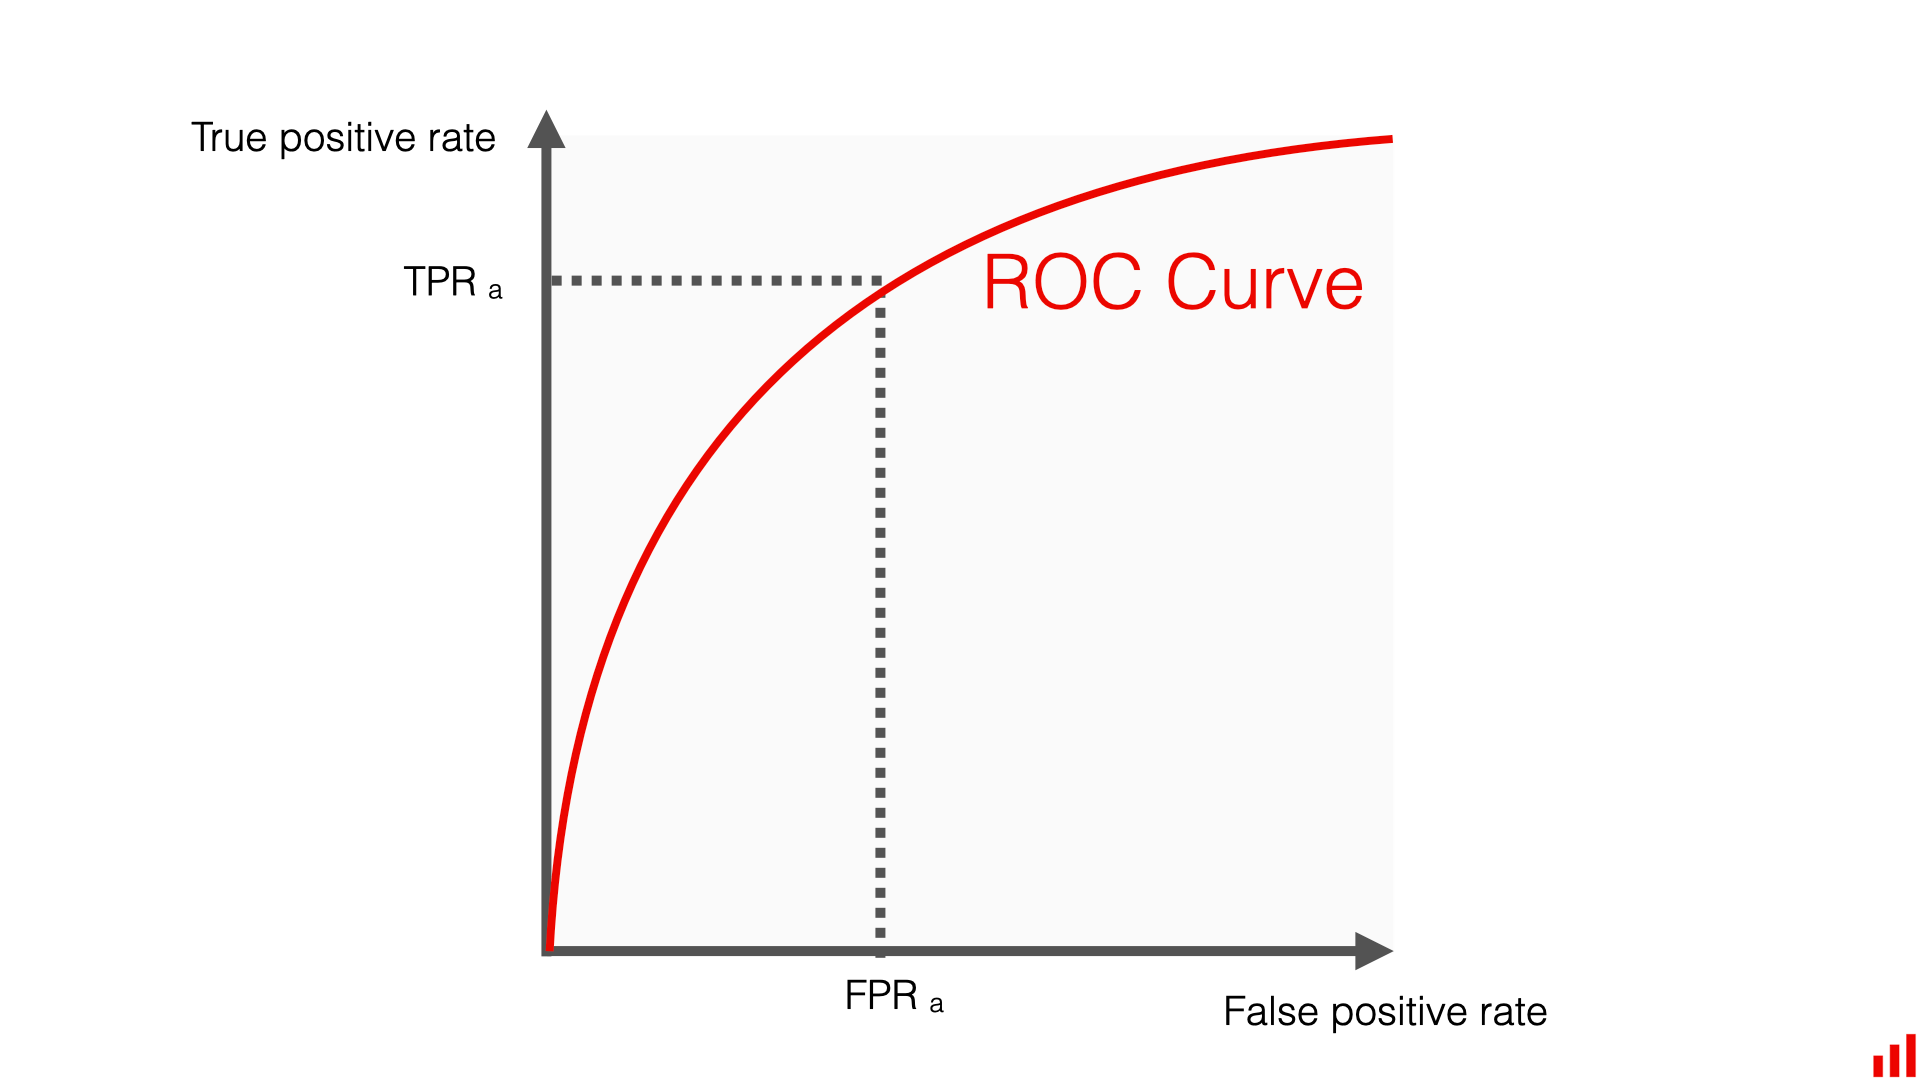

Un graphique qui illustre les performances d'un modèle de classification binaire à différents seuils de discrimination. Elle trace le Rappel (TPR) sur l'axe des y (vertical) en fonction du Taux de Faux Positifs (FPR) sur l'axe des x (horizontal), pour tous les seuils de classification possibles.

### **Étape 4.1 : évaluation des performances du modèle**


Utilisez les fonctions suivantes de scikit learn pour chaque métrique expliquée précédemment:
- `accuracy_score` 
- `precision_score`
- `recall_score`
- `f1_score`
- `roc_auc_score`

In [ ]:
print("\n--- Évaluation des Performances du Modèle ---")

accuracy = 
precision = 
recall = 
f1 = 
roc_auc = 

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC Score : {roc_auc:.4f}")

print("\nInterprétation des métriques :")
print("  - **Accuracy :** La proportion de prédictions correctes. Attention, peut être trompeuse en cas de classes déséquilibrées.")
print("  - **Precision (Précision) :** Parmi tous les patients que le modèle a prédits comme ayant un cancer, quelle proportion en avait réellement un. Utile quand le coût d'un faux positif est élevé (ex: traitement inutile).")
print("  - **Recall (Rappel ou Sensibilité) :** Parmi tous les patients ayant réellement un cancer, quelle proportion le modèle a-t-il correctement identifiée. Utile quand le coût d'un faux négatif est élevé (ex: un cancer non détecté).")
print("  - **F1-Score :** Une moyenne harmonieuse entre Precision et Recall. Bon indicateur pour évaluer le modèle quand les classes sont déséquilibrées et que l'on veut un équilibre entre Precision et Recall.")
print("  - **ROC AUC Score :** Mesure la capacité du modèle à distinguer les classes. Une valeur de 0.5 indique un modèle aléatoire, et 1.0 un classifieur parfait. Très robuste aux déséquilibres de classes.")

### **Étape 4.2 : Visualisation des résultats du modèle**

Il est possible de visualiser la **matrice de confusion** à l'aide de la fonction `confusion_matrix` et la **courbe ROC**  à l'aide des fonctions `roc_curve` et `roc_auc_score`

In [ ]:
print("\n--- Visualisation de la matrice de confusion ---")

cm = 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO Cancer (0)', 'YES Cancer (1)'])

disp.plot(cmap='Blues', values_format='d')
plt.title('Matrice de Confusion')
plt.show()

print("\nInterprétation de la Matrice de Confusion :")
print("  - **Vrais Positifs (VP) (en bas à droite) :** Cas de cancer correctement identifiés.")
print("  - **Vrais Négatifs (VN) (en haut à gauche) :** Cas sans cancer correctement identifiés.")
print("  - **Faux Positifs (FP) (en haut à droite) :** Cas sans cancer prédits à tort comme ayant un cancer.")
print("  - **Faux Négatifs (FN) (en bas à gauche) :** Cas de cancer manqués par le modèle.")

**Courbe ROC (Receiver Operating Characteristic) et AUC**

In [ ]:
print("\n--- Visualisation de la Courbe ROC ---")

fpr, tpr, thresholds = 
roc_auc = 

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR) / Rappel')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("\nInterprétation de la Courbe ROC :")
print("  - La courbe ROC montre le compromis entre le taux de vrais positifs (Rappel) et le taux de faux positifs à différents seuils.")
print("  - Plus la courbe se rapproche du coin supérieur gauche (où TPR=1 et FPR=0), meilleure est la performance du classifieur.")
print("  - L'AUC est la surface sous la courbe. Une valeur de 0.5 indique un modèle aléatoire, et 1.0 un classifieur parfait. Très robuste aux déséquilibres de classes.")

## **Partie 5 : Synthèse et conclusions**

### **Questions à vous poser avant de déployer un modèle**

1. **Le modèle est-il cliniquement pertinent ?**
   - Détecte-t-il suffisamment de cancers (Recall supérieur à un certain seuil) ?
   - Les fausses alertes sont-elles acceptables (Precision supérieure à un certain seuil) ?

2. **Qu'est-ce qui est plus grave ?**
   - Manquer un cancer (FN → ajuster seuil bas)
   - Traiter à tort un patient sain (FP → ajuster seuil haut)

3. **Les données sont-elles représentatives ?**
   - La distribution d'entraînement ressemble-t-elle à l'usage réel ?
   - Y a-t-il un biais démographique ?

4. **Peut-on s'améliorer ?**
   - Feature engineering ?
   - Tuning des hyperparamètres (GridSearchCV) ?
   - Ensemble methods (voting, stacking) ?

# **Partie bonus : comparaison des performances de plusieurs modèles**

**scikit-learn** propose plusieurs méthodes d’apprentissage supervisé pour effectuer des tâches de classification. Dans cette partie, l’objectif est d’explorer d’autres modèles que la régression logistique pour prédire la présence ou l'absence d'un cancer. Parmi les options disponibles, on trouve par exemple [SVM](https://scikit-learn.org/stable/api/sklearn.svm.html) (Support Vector Machines) ou [Random Forest](https://scikit-learn.org/stable/api/sklearn.ensemble.html).



**Tâche :** À partir de la documentation de scikit-learn et des étapes précédentes, entraînez un modèle de type Random Forest ou SVM. Comparez ensuite ses performances à celles obtenues avec la régression logistique, et analysez les résultats en commentant les différences observées.